**Table of contents**<a id='toc0_'></a>    
1.1. [Load Data](#toc1_1_)    
1.2. [Data Visualization](#toc1_2_)    
1.3. [Assumptions Check](#toc1_3_)    
1.3.1. [Dependency check](#toc1_3_1_)    
1.3.2. [Normality & Homoscedasticity Assumptions Check](#toc1_3_2_)    
1.4. [Analyse of Variances](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
import pingouin as pg


In [2]:
plt.style.use('seaborn-v0_8-notebook')

## 1.1. <a id='toc1_1_'></a>[Load Data](#toc0_)

In [15]:
import openpyxl as xl

sheet_names= xl.load_workbook("data/data_num.xlsx").sheetnames

def load_data(file_path="data/data_num.xlsx", sheet=sheet_names[0]):
    return pd.read_excel(file_path, sheet_name=sheet)
df_widgets = widgets.interactive(
    load_data,
    sheet=widgets.Dropdown(options=sheet_names, value=sheet_names[0])
    )
df_widgets

interactive(children=(Text(value='data/data_num.xlsx', description='file_path'), Dropdown(description='sheet',…

In [16]:
df = pd.read_excel("data/data.xlsx")
df.head()

,Date,LC2A,MP2,MP1,MC
0,22/10/2025 18:00,721.0,870.75,845.12,850.2
1,22/10/2025 20:00,650.0,760.20,848.10,889.8
2,22/10/2025 22:30,644.0,638.40,749.00,682.3
3,23/10/2025 01:00,636.0,552.70,741.00,658.2
4,23/10/2025 04:00,649.0,607.42,755.40,670.2


In [141]:
df = sns.load_dataset('titanic').drop(columns=['age', 'fare']).astype('category')
df.head()

,survived,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,1,0,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,1,0,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,0,0,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,1,0,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,0,0,S,Third,man,True,NaN,Southampton,no,True


In [142]:
stats_summary = df.describe().T
stats_summary

,count,unique,top,freq
survived,891,2,0,549
pclass,891,3,3,491
sex,891,2,male,577
sibsp,891,7,0,608
parch,891,7,0,678
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59


## 1.2. <a id='toc1_2_'></a>[Data Visualization](#toc0_)

In [143]:
def catplot(data, x, hue):
    sns.catplot(data=data, kind='count', x=x, hue=hue, height=4, aspect=1.5, legend_out=False)

widgets.interact(catplot, data=widgets.fixed(df), x=widgets.Dropdown(options=df.columns), hue=widgets.Dropdown(options=[None]+list(df.columns)))

interactive(children=(Dropdown(description='x', options=('survived', 'pclass', 'sex', 'sibsp', 'parch', 'embar…

<function __main__.catplot(data, x, hue)>

In [144]:
from itertools import combinations

combs = list(combinations(df.select_dtypes(include='category'), 2))

In [145]:
associations = []
for x, y in combs:
	association = pg.chi2_independence(df, x=x, y=y)[2]
	association.insert(0, 'Var1', x)
	association.insert(1, 'Var2', y)
	associations.append(association)
associations_result = pd.concat(associations)


/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/pingouin/contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/pingouin/contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/scipy/stats/_stats_py.py:7286: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/scipy/stats/_stats_py.py:7286: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/scipy/stats/_stats_py.py:7283: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)
/home/rammah/

In [146]:
associations_result.sort_values(by='cramer', ascending=False).dropna(subset='pval')

,Var1,Var2,test,lambda,chi2,dof,pval,cramer,power
4,deck,alone,mod-log-likelihood,-1.000000,inf,6.0,0.000000,inf,NaN
4,deck,embark_town,mod-log-likelihood,-1.000000,inf,12.0,0.000000,inf,NaN
4,survived,parch,mod-log-likelihood,-1.000000,inf,6.0,0.000000,inf,NaN
4,pclass,sibsp,mod-log-likelihood,-1.000000,inf,12.0,0.000000,inf,NaN
4,who,adult_male,mod-log-likelihood,-1.000000,inf,2.0,0.000000,inf,NaN
...,...,...,...,...,...,...,...,...,...
5,who,embark_town,neyman,-2.000000,14.054799,4.0,0.007122,0.088809,0.541868
1,parch,class,cressie-read,0.666667,13.524082,12.0,0.332125,0.087116,0.336354
1,pclass,parch,cressie-read,0.666667,13.524082,12.0,0.332125,0.087116,0.336354
0,pclass,parch,pearson,1.000000,12.870292,12.0,0.378539,0.084985,0.319260


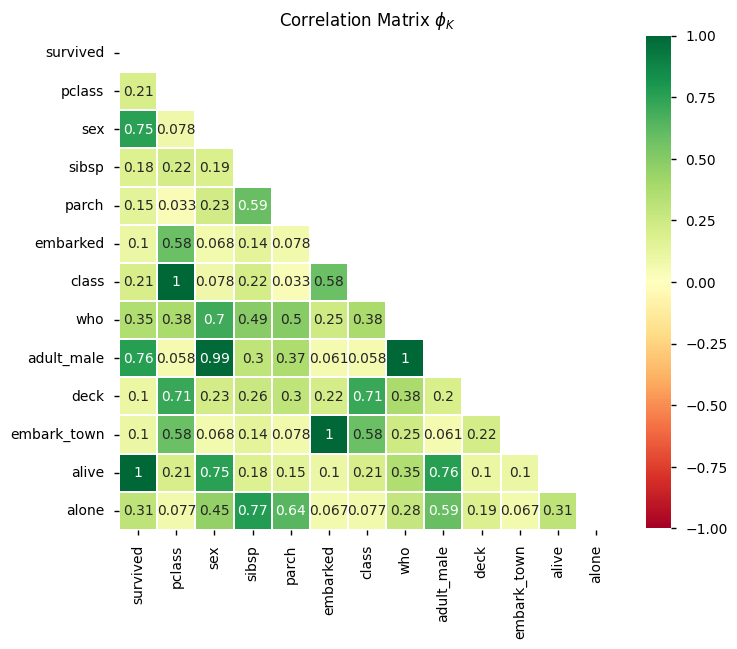

In [147]:
import phik
from phik import resources, report

# open fake car insurance data


# Pearson's correlation matrix between numeric variables (pandas functionality)

# get the phi_k correlation matrix between all variables
corr_matrix = df.phik_matrix()
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[int(df.shape[1]/1.5),int(df.shape[1]/1.5)])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			square=True,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title(r'Correlation Matrix $\phi_K$');


/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


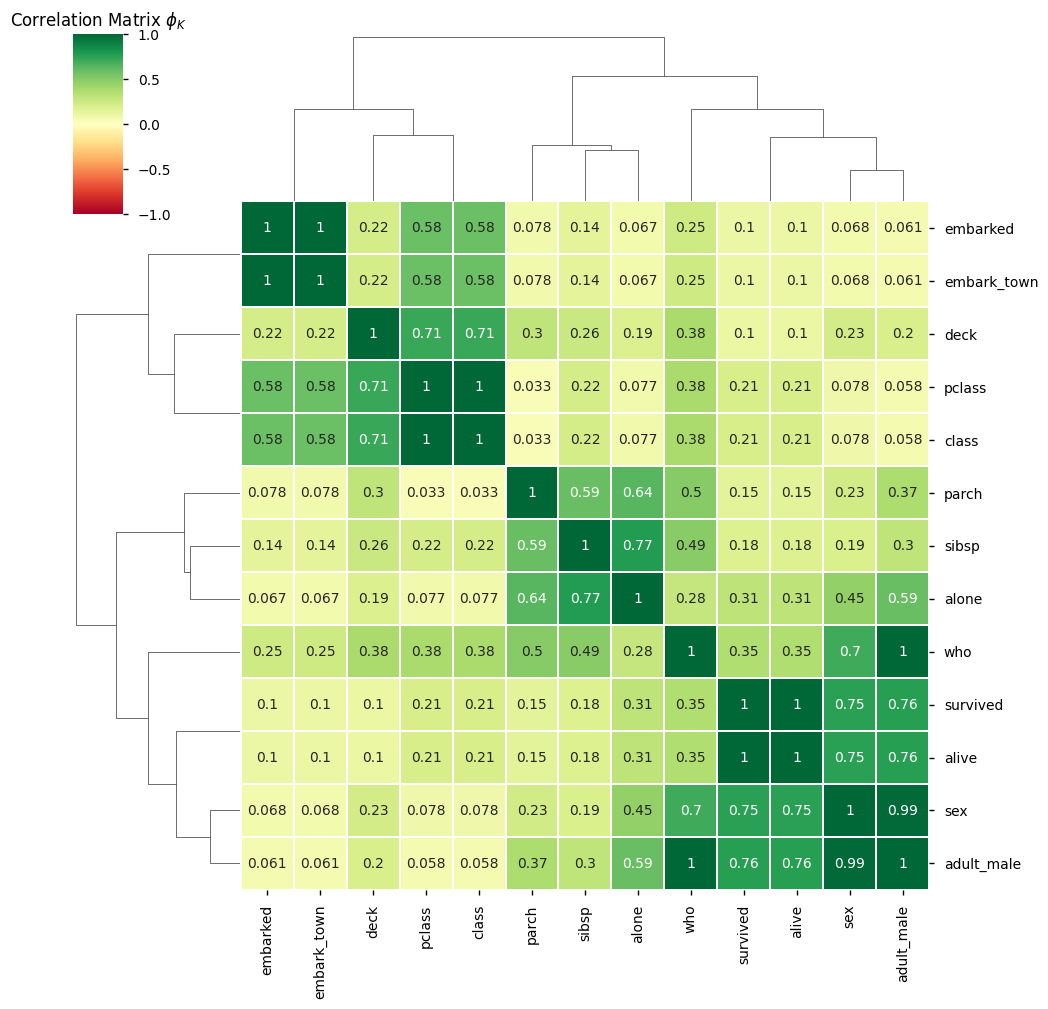

In [148]:
sns.clustermap(corr_matrix, 
			linewidths=0.1,
			square=True,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title(r'Correlation Matrix $\phi_K$');

/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/phik/phik.py:314: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.380249044552353e-33.
  Vinv = inv(V)
/home/rammah/miniconda3/envs/ml_env/lib/python3.13/site-packages/phik/phik.py:319: RuntimeWarning: invalid value encountered in sqrt
  global_correlations = np.sqrt(


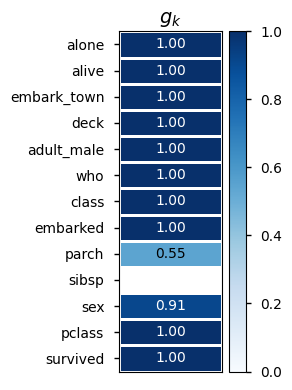

In [149]:

# get global correlations based on phi_k correlation matrix
global_correlation, global_labels = df.global_phik()
report.plot_correlation_matrix(global_correlation, x_labels=[''], y_labels=global_labels, 
                        vmin=0, vmax=1, figsize=(3,4),
                        color_map='Blues', title=r'$g_k$',
                        fontsize_factor=1.)
plt.tight_layout()
